<a href="https://colab.research.google.com/github/cfgramoso/1659-postgresql-primeiros-passos/blob/aula-1/02_tdc2025_parte1_brincando_com_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução aos Desafios de Lidar com Dados para o Mercado Financeiro

Lidar com dados financeiros pode ser desafiador devido a várias razões. Alguns dos principais desafios incluem:

1. **Dados Incompletos ou Ausentes**: Em muitos casos, os dados financeiros podem ter lacunas, como dias sem negociação (feriados, fins de semana, etc.). Isso pode afetar a análise e a modelagem dos dados.

2. **Normalização de Dados**: Para comparar diferentes ativos ou índices, é necessário normalizar os dados. Isso pode incluir o preenchimento de lacunas, ajuste de preços para eventos corporativos (dividendos, splits, etc.), e ajuste para inflação.

3. **Cálculo de Variação e Variação Acumulada**: Para analisar o desempenho de ativos e índices, é comum calcular a variação diária e a variação acumulada dos preços. Isso permite comparar o desempenho relativo de diferentes ativos ao longo do tempo.


# Setup do Google Drive & Download Workshop Files
> ℹ️ Para Baixar os Arquivos do Workshop

In [ ]:
import os

gdrive_basepath='/content/drive/MyDrive/tdc_2025_data'
URL_GIST_MAP='https://gist.githubusercontent.com/fnldesign/d301635c034e4868f7ba557b0429e523/raw/6e94e7a9df7265b42438cf46bd8c705fa2ef1d66/gist_map.csv'
gistmap_filepath = os.path.join(gdrive_basepath, 'gist_map.csv')
download_error = True

def mount_gdrive():
  global gdrive_basepath
  if 'google.colab' in str(get_ipython()):
    from google.colab import drive
    try:
      drive.mount('/content/drive')
      gdrive_basepath='/content/drive/MyDrive/tdc_2025_data'
      print(f'✅ Google Drive montado!')
    except Exception as e:
      print(f'❌ Erro ao montar o Google Drive. Erro: {e}')
      gdrive_basepath='tdc_2025_data'
  else:
      print("This notebook is not running in Google Colab environment. Setting Local Base Path")
      gdrive_basepath='tdc_2025_data'


def download_files():
  import urllib.request
  import pandas as pd

  global download_error

  try:
    url = URL_GIST_MAP
    urllib.request.urlretrieve(url, gistmap_filepath)
    print(f'✅ Arquivo gist_map.csv baixado com sucesso!')
  except Exception as e:
    print(f'❌ Erro ao baixar o arquivo gist_map.csv. Erro: {e}')
    return

  df_files = pd.read_csv(gistmap_filepath)
  df_files = df_files[df_files['file_name'] != 'gist_map.csv']


  print(f'📂 Baixando arquivos...')
  for index, row in df_files.iterrows():
      try:
        url = row['gist_raw_url']
        file_name = row['file_name']
        print(f'Downloading {index+1}/{len(df_files)}:{file_name}...')
        file_path = os.path.join(gdrive_basepath, file_name)
        urllib.request.urlretrieve(url, file_path)
      except Exception as e:
        print(f'❌ Erro ao baixar o arquivo {file_name}. Erro: {e}')
        if not download_error:
          download_error = True
        continue
      finally:
        if not download_error:
          download_error = False

  if not download_error:
    print(f'✅ Arquivos baixados com sucesso!')

mount_gdrive()
os.makedirs(gdrive_basepath, exist_ok=True)
download_files()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado!
✅ Arquivo gist_map.csv baixado com sucesso!
📂 Baixando arquivos...


# Setup das Libs

In [ ]:
!pip install pandas numpy seaborn matplotlib plotly nbformat
!pip install --upgrade yfinance
!pip install importlib_resources

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import yfinance as yf
import requests

# Carregando alguns Dados

Trabalhar com dados financeiros pode ser desafiador e, às vezes, frustrante. Aqui estão alguns memes que ilustram os problemas comuns que enfrentamos:


![Meme 3](https://estatsite.com.br/wp-content/uploads/2020/05/EWo77pGXsAAfwXw.jpg)


![Meme 1](https://estatsite.com.br/wp-content/uploads/2020/05/ESI3gltWsAY2uEO.jpg)




## 1. Dados Faltantes

In [ ]:
df_dolar=pd.read_csv(os.path.join(gdrive_basepath, 'dolar_historico.csv'))
print('Dolar Antes')
print(df_dolar.head(10))

# Vamos converter a coluna data para o tipo datetime
df_dolar['data'] = pd.to_datetime(df_dolar['data'])

# Vamos preencher os dias que não tem valor com o valor do dia anterior
# Modo complicado!
df_dolar = df_dolar.set_index('data').resample('D').asfreq().fillna(method='ffill').reset_index()

# Modo fácil!
# Vamos preencher os dias que não tem valor com o valor do dia anterior
df_dolar['valor'] = df_dolar['valor'].ffill()

# Reordenando o dataframe
df_dolar = df_dolar.sort_values('data', ascending=False)

print('\nDolar Depois')
print(df_dolar.head(10))

Dolar Antes
         data   valor
0  2025-03-21  5.7241
1  2025-03-20  5.6628
2  2025-03-19  5.6657
3  2025-03-18  5.6852
4  2025-03-17  5.7082
5  2025-03-14  5.7419
6  2025-03-13  5.8131
7  2025-03-12  5.8268
8  2025-03-11  5.8346
9  2025-03-10  5.7930

Dolar Depois
            data   valor
14723 2025-03-21  5.7241
14722 2025-03-20  5.6628
14721 2025-03-19  5.6657
14720 2025-03-18  5.6852
14719 2025-03-17  5.7082
14718 2025-03-16  5.7419
14717 2025-03-15  5.7419
14716 2025-03-14  5.7419
14715 2025-03-13  5.8131
14714 2025-03-12  5.8268


<ipython-input-4-22ac492d25c5>:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_dolar = df_dolar.set_index('data').resample('D').asfreq().fillna(method='ffill').reset_index()


### Visualizando os Dados

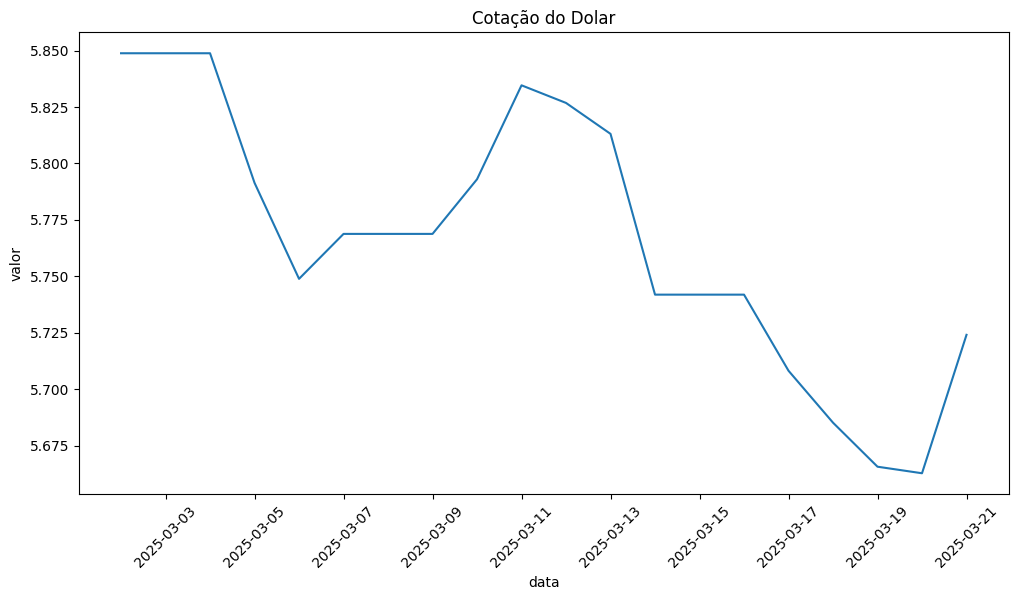

In [ ]:
# Vamos plotar o gráfico
plt.figure(figsize=(12,6))
sns.lineplot(data=df_dolar.head(20), x='data', y='valor')
plt.xticks(rotation=45)
plt.title('Cotação do Dolar')
#plt.grid()
plt.show()

### 2. Será que podemos confiar nos dados gratuitos?

#### Libs com problemas ou erros!

In [ ]:
# Downloading VALE3 data using yfinance
ticker_vale3 = yf.Ticker("VALE3.SA")
df_vale3 = ticker_vale3.history(period="1y", interval="1d")
df_vale3 = df_vale3[['Open', 'High', 'Low', 'Close', 'Volume']]

# Filtrar para incluir apenas os registros com volume maior que 0
df_vale3 = df_vale3[df_vale3['Volume'] == 0]

# Display the first few rows of the dataframe
print(df_vale3.head())

                                Open       High        Low      Close  Volume
Date                                                                         
2024-04-26 00:00:00-03:00  57.261276  57.261276  57.261276  57.261276       0
2025-03-25 00:00:00-03:00   0.000000   0.000000   0.000000  57.340000       0


#### 3. Dados Não Padronizados!

In [ ]:
user_agent = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
headers = {
  "User-Agent": user_agent
}
url = "https://query1.finance.yahoo.com/v8/finance/chart/VALE3.SA?range=1y&interval=1d"

response = requests.get(url, headers=headers)
data = response.json()

if response.status_code == 200:
  data = response.json()
else:
  print(f"Error: Unable to fetch data, status code {response.status_code}")
  data = {}

# Olha essa API! Que coisa linda! SQN!
#{
#"chart": {
#  "result": [
#    {
#    "meta": {},
#    "timestamp": [],
#    "indicators": {
#    "quote": [
#      {
#      "high": [],
#      "close": [],
#      "volume": [
#      18445500,
#      11058400,
#      10478200,
# E o que temos que fazer para extrair os dados e transformar em um dataframe!
valores_ohlcv = {
  'open': data['chart']['result'][0]['indicators']['quote'][0]['open'],
  'high': data['chart']['result'][0]['indicators']['quote'][0]['high'],
  'low': data['chart']['result'][0]['indicators']['quote'][0]['low'],
  'close': data['chart']['result'][0]['indicators']['quote'][0]['close'],
  'volume': data['chart']['result'][0]['indicators']['quote'][0]['volume']
}
datas = data['chart']['result'][0]['timestamp']

# Quem quer visualizar as datas como timestamp? Vamos converter para datetime
df_vale3 = pd.DataFrame.from_dict(valores_ohlcv).set_index(pd.to_datetime(datas, unit='s'))
df_vale3.index.name = 'timestamp'
df_vale3 = df_vale3.round(2)

print(df_vale3.head())


                      open   high    low  close    volume
timestamp                                                
2024-03-25 13:00:00  61.02  61.32  60.65  60.82  10478200
2024-03-26 13:00:00  60.31  60.52  59.59  60.05  27142700
2024-03-27 13:00:00  59.80  60.67  59.69  60.60  23927000
2024-03-28 13:00:00  60.62  61.09  60.07  60.83  18467000
2024-04-01 13:00:00  61.60  61.90  61.00  61.22  16740100


In [ ]:
# Vamos plotar o gráfico de candlestick
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x=df_vale3.index,
                open=df_vale3['open'],
                high=df_vale3['high'],
                low=df_vale3['low'],
                close=df_vale3['close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()



#### Essa a gente já sabe corrigir!

In [ ]:
# Preencher datas faltantes no df_vale3
df_vale3 = df_vale3.asfreq('D', method='ffill')

# Vamos plotar o gráfico de candlestick
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x=df_vale3.index,
                open=df_vale3['open'],
                high=df_vale3['high'],
                low=df_vale3['low'],
                close=df_vale3['close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

## Agora Fazendo coisas sérias! Que precisamos!

![Meme 2](https://media.licdn.com/dms/image/v2/C4E12AQEfj7KiMSS-og/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1537410548893?e=2147483647&v=beta&t=i6qu6E_XS75lfNP4kZauUAUB6cN1oUU6V3xho2ju2DM)


### Para comparar indicadores precisamos colocá-los na mesma base de comparação
> É ai que entra calcular a variação

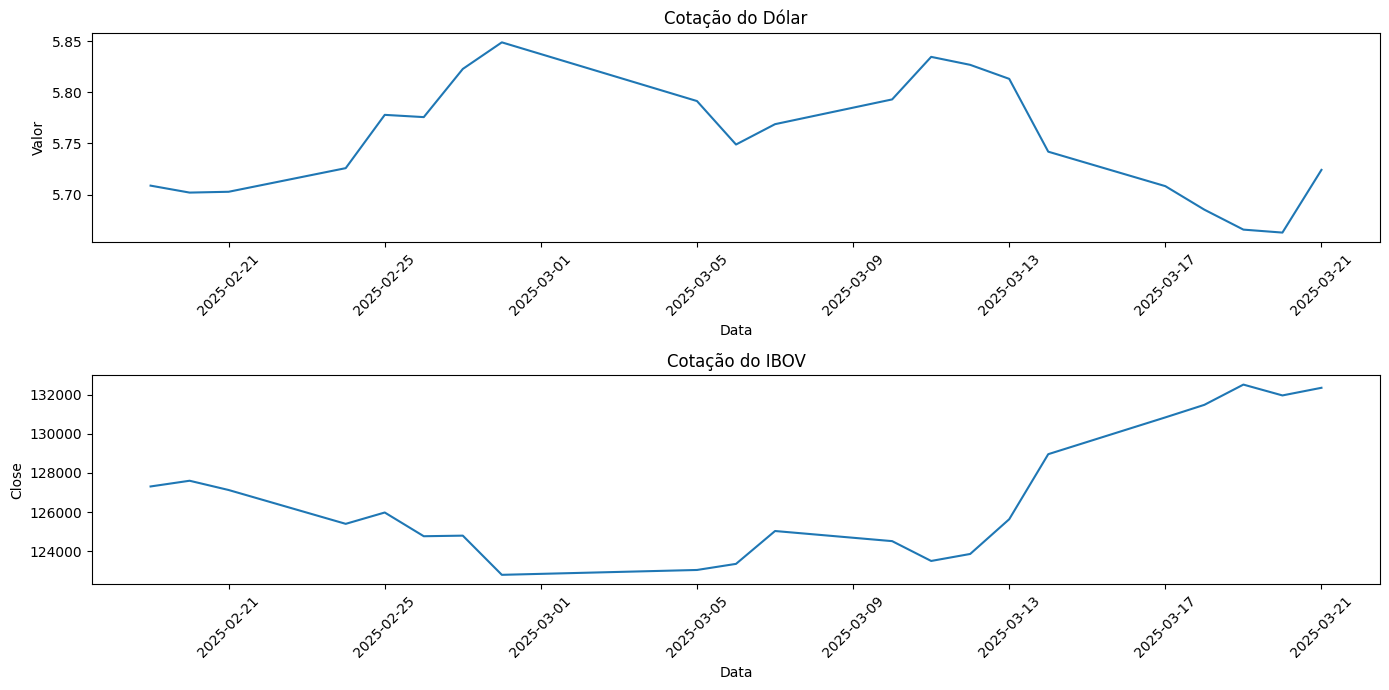

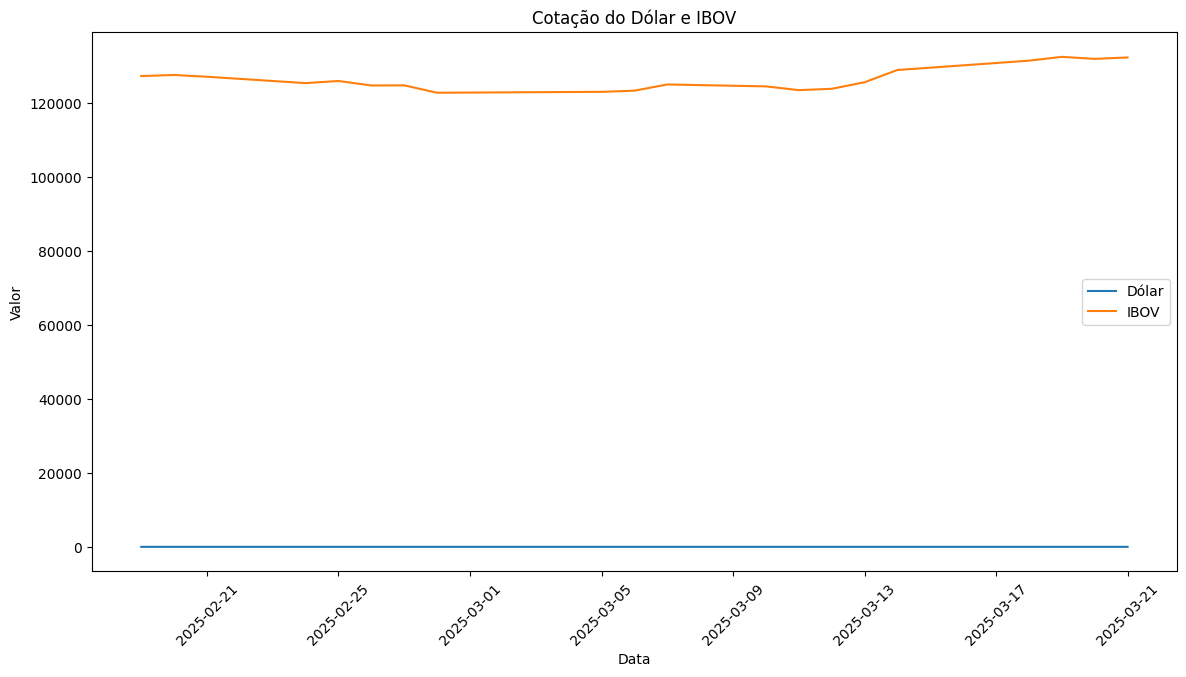

In [ ]:
df_dolar=pd.read_csv(os.path.join(gdrive_basepath, 'dolar_historico.csv'))
df_ibov=pd.read_csv(os.path.join(gdrive_basepath, 'ibovespa_historico.csv'))

df_dolar['data'] = pd.to_datetime(df_dolar['data'])
df_ibov['date'] = pd.to_datetime(df_ibov['date'])

# Filtrar os registros para mostrar somente os últimos 30 dias
df_dolar = df_dolar[df_dolar['data'] >= df_dolar['data'].max() - pd.Timedelta(days=30)]
df_ibov = df_ibov[df_ibov['date'] >= df_ibov['date'].max() - pd.Timedelta(days=30)]

# Plotando os gráficos de valores de Dólar e IBOV
plt.figure(figsize=(14, 7))

# Gráfico do Dólar
plt.subplot(2, 1, 1)
sns.lineplot(data=df_dolar, x='data', y='valor')
plt.title('Cotação do Dólar')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.xticks(rotation=45)

# Gráfico do IBOV
plt.subplot(2, 1, 2)
sns.lineplot(data=df_ibov, x='date', y='close')
plt.title('Cotação do IBOV')
plt.xlabel('Data')
plt.ylabel('Close')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Plotando os gráficos de valores de Dólar e IBOV em um único gráfico
plt.figure(figsize=(14, 7))

# Gráfico do Dólar
sns.lineplot(data=df_dolar, x='data', y='valor', label='Dólar')

# Gráfico do IBOV
sns.lineplot(data=df_ibov, x='date', y='close', label='IBOV')

plt.title('Cotação do Dólar e IBOV')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.legend()
plt.show()

### Ajustando, comparando pela variação

        data   valor  variacao_dolar
0 2025-03-21  5.7241             NaN
1 2025-03-20  5.6628       -1.070911
2 2025-03-19  5.6657        0.051211
3 2025-03-18  5.6852        0.344176
4 2025-03-17  5.7082        0.404559
           date      open      high       low     close  adjusted_close  \
1223 2025-02-19  128528.0  128528.0  127028.0  127309.0        127309.0   
1224 2025-02-20  127309.0  127871.0  127063.0  127601.0        127601.0   
1225 2025-02-21  127601.0  127654.0  126483.0  127128.0        127128.0   
1226 2025-02-24  127129.0  127275.0  125162.0  125401.0        125401.0   
1227 2025-02-25  125401.0  126718.0  125382.0  125980.0        125980.0   

        volume  variacao_ibov  
1223   9295100            NaN  
1224  10640300       0.229363  
1225  11093300      -0.370687  
1226  10148900      -1.358473  
1227  11078000       0.461719  


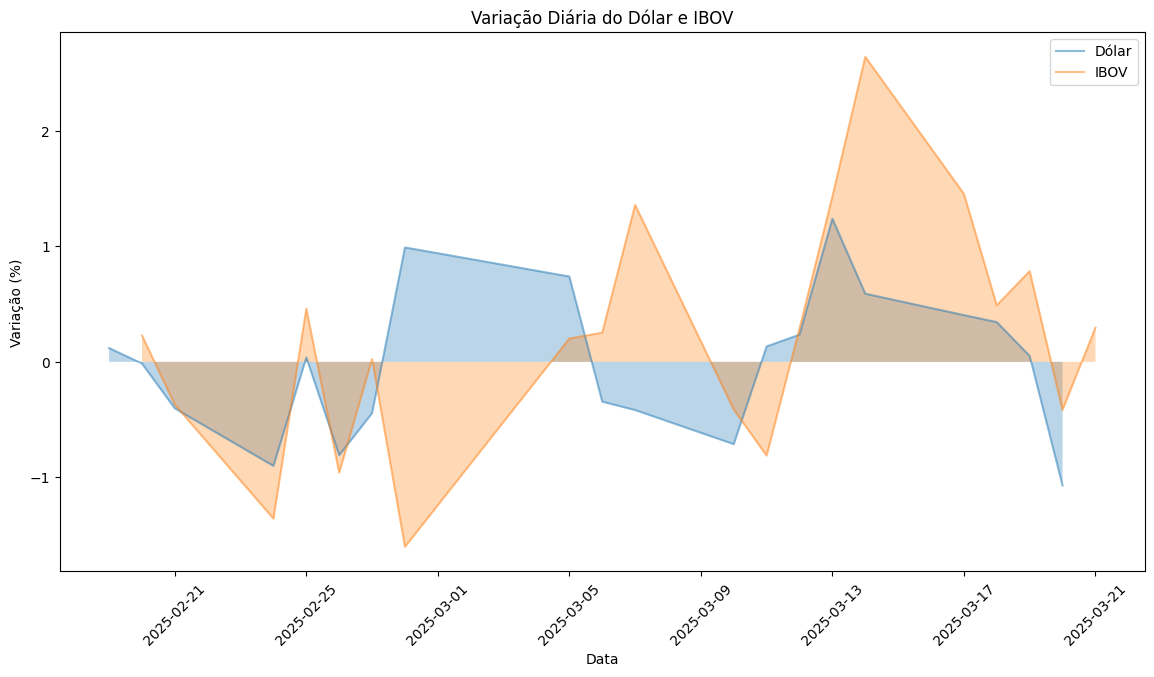

In [ ]:
# Calculando a variação diária do Dólar
df_dolar['variacao_dolar'] = df_dolar['valor'].pct_change() * 100

# Calculando a variação diária do IBOV
df_ibov['variacao_ibov'] = df_ibov['close'].pct_change() * 100

# Exibindo as primeiras linhas dos dataframes atualizados
print(df_dolar.head())
print(df_ibov.head())

# Plotando os gráficos de variação diária de Dólar e IBOV em um único gráfico de área
plt.figure(figsize=(14, 7))

# Gráfico de área do Dólar
sns.lineplot(data=df_dolar, x='data', y='variacao_dolar', label='Dólar', alpha=0.5)
plt.fill_between(df_dolar['data'], df_dolar['variacao_dolar'], alpha=0.3)

# Gráfico de área do IBOV
sns.lineplot(data=df_ibov, x='date', y='variacao_ibov', label='IBOV', alpha=0.5)
plt.fill_between(df_ibov['date'], df_ibov['variacao_ibov'], alpha=0.3)

plt.title('Variação Diária do Dólar e IBOV')
plt.xlabel('Data')
plt.ylabel('Variação (%)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

### Olhando com a Variação Acumulada para Compreender Correlação

        data   valor  variacao_dolar  variacao_acumulada_dolar
0 2025-03-21  5.7241             NaN                       NaN
1 2025-03-20  5.6628       -1.070911                 -1.070911
2 2025-03-19  5.6657        0.051211                 -1.019699
3 2025-03-18  5.6852        0.344176                 -0.675523
4 2025-03-17  5.7082        0.404559                 -0.270964
           date      open      high       low     close  adjusted_close  \
1223 2025-02-19  128528.0  128528.0  127028.0  127309.0        127309.0   
1224 2025-02-20  127309.0  127871.0  127063.0  127601.0        127601.0   
1225 2025-02-21  127601.0  127654.0  126483.0  127128.0        127128.0   
1226 2025-02-24  127129.0  127275.0  125162.0  125401.0        125401.0   
1227 2025-02-25  125401.0  126718.0  125382.0  125980.0        125980.0   

        volume  variacao_ibov  variacao_acumulada_ibov  
1223   9295100            NaN                      NaN  
1224  10640300       0.229363                 0.229363  


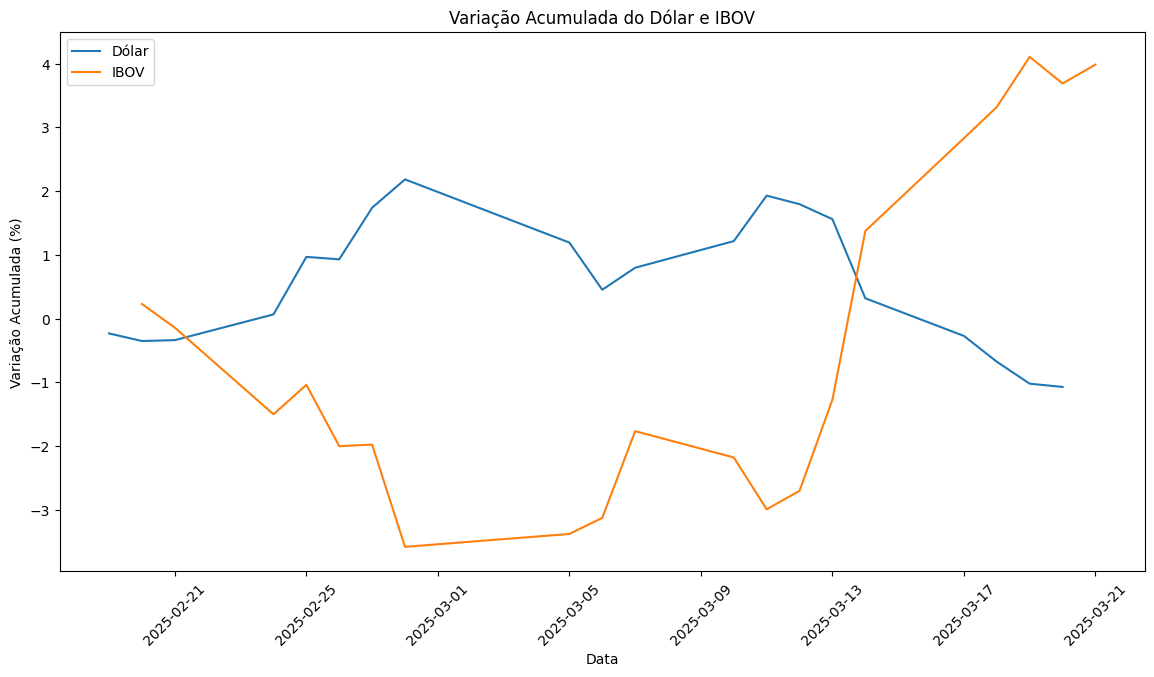

In [ ]:
# Calculando a variação acumulada do Dólar
df_dolar['variacao_acumulada_dolar'] = df_dolar['variacao_dolar'].cumsum()

# Calculando a variação acumulada do IBOV
df_ibov['variacao_acumulada_ibov'] = df_ibov['variacao_ibov'].cumsum()

# Exibindo as primeiras linhas dos dataframes atualizados
print(df_dolar.head())
print(df_ibov.head())

# Plotando os gráficos de variação acumulada de Dólar e IBOV em um único gráfico
plt.figure(figsize=(14, 7))

# Gráfico do Dólar
sns.lineplot(data=df_dolar, x='data', y='variacao_acumulada_dolar', label='Dólar')

# Gráfico do IBOV
sns.lineplot(data=df_ibov, x='date', y='variacao_acumulada_ibov', label='IBOV')

plt.title('Variação Acumulada do Dólar e IBOV')
plt.xlabel('Data')
plt.ylabel('Variação Acumulada (%)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

## E agora vamos entender um pouco mais a fundo o contexto

![Mapa Mental](https://github.com/dadosnapratica/tdc2025_content/blob/main/Mapa-Mental.png?raw=true)

[Link para o Mapa Mental](https://mm.tt/app/map/3639069292?t=sUTizjY1tx)

### E ai que vamos precisar de ferramentas..Como essas!

Apache Airflow

![DAG Dependencies](https://github.com/dadosnapratica/tdc2025_content/blob/main/Airflow-DAG-Dependencies.png?raw=true)

![Dag Schedulers](https://github.com/dadosnapratica/tdc2025_content/blob/main/Airflow-DAG-Schedulers.png?raw=true)

[Link para Documentação do Airflow](https://airflow.apache.org/docs/apache-airflow/stable/index.html)

<br>
<br>

Apache Hop

![Apache Hop](https://github.com/dadosnapratica/tdc2025_content/blob/main/ApacheHopScreen.png?raw=true)
[Link para Apache Hop - Getting Strated](https://hop.apache.org/manual/latest/getting-started/)

### ...E essas. API Management, IPaaS!

> Além do Classico Airflow ou qualquer outro scheduller de jobs, precisamos de ferramentas que organizem as interface ou fluxos de integração


![SensediaAPIManagement]()
[Link para o Sensedia API Management](https://www.sensedia.com/product/api-management)

![SensediaIntegrations]()
[Link para o Sensedia API Integrations](https://www.sensedia.com/product/integrations)

![SensediaAdptativeGovernance]()
[Link para o Sensedia Adptative Governance](https://www.sensedia.com/product/api-governance)

### E Essas! ... Arquiteturas Escaláveis em Cloud

![DataBricks](https://learn.microsoft.com/pt-br/azure/architecture/solution-ideas/media/azure-databricks-modern-analytics-architecture.svg)

![AWS Data AI](https://github.com/dadosnapratica/tdc2025_content/blob/main/AWS-Data_IA_Architecture.png?raw=true)

![Oracle Cloud DataProcessing](https://github.com/dadosnapratica/tdc2025_content/blob/main/oci-bulk-data-integration-architecture-diagram-oracle.png?raw=true)

**OS DESAFIOS VÃO ALÉM DE FERRAMENTAS....**

[DEVOPS]
[DATAOPS]
[MLOPS/IAOPS]
[DATAGOVERNANCE]
[DATALAKEHOUSE]


## Agora vamos para a coisa séria! Montando uma carteira QUANT!

$$ \text{Dívida Líquida/EBITDA} = \frac{\text{Dívida Bruta} - \text{Caixa e Equivalentes}}{\text{EBITDA}} $$ / $$ EV/EBITDA = \frac{\text{Valor de Mercado} + \text{Dívida Líquida}}{\text{EBITDA}} $$

<br>
<br>

[Link par Parte 2 - O RECHEIO É ANALISE QUANTITATIVA](https://gist.github.com/fnldesign/794253c6bb6eb034cc84b932b5c870b5)